**EcoSort AI – Waste Classification Using CNN** 
 Final Project Notebook  

This project focuses on classifying different categories of waste using a Convolutional Neural Network (CNN) trained using "Teachable Machine".  
The goal is to support sustainability by automating waste segregation through image classification.

---


 **Problem Statement**

Waste mismanagement is a major environmental issue. Manual waste segregation is slow, inefficient, and prone to mistakes.  
This project aims to develop an AI-powered waste classification system using "Deep Learning and CNNs" to automatically identify:

- Plastic  
- Paper  
- Metal  
- Cardboard  
- Biological waste  
- Clothes  
- Shoes  
- Trash  

By automating waste sorting, EcoSort AI contributes to sustainable disposal, recycling, and resource conservation.


In [1]:
import tensorflow as tf
import numpy as np
from keras.models import load_model
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.15.0


In [4]:
MODEL_PATH = "./model/keras_model.h5"
LABELS_PATH = "./model/labels.txt"

model = load_model(MODEL_PATH, compile=False)

class_names = [line.strip()[2:] for line in open(LABELS_PATH)]
print("Model and labels loaded successfully.")




Model and labels loaded successfully.


In [7]:
def predict_image(image_path):
    size = (224, 224)
    
    image = Image.open(image_path).convert("RGB")
    img_resized = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    
    img_array = np.asarray(img_resized).astype(np.float32)
    normalized = (img_array / 127.5) - 1
    data = np.expand_dims(normalized, axis=0)
    
    prediction = model.predict(data)
    index = np.argmax(prediction)
    
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[index]}  ({prediction[0][index]*100:.2f}%)")
    plt.show()
    
    return class_names[index], prediction[0][index]


1/1 [==============================] - 2s 2s/step


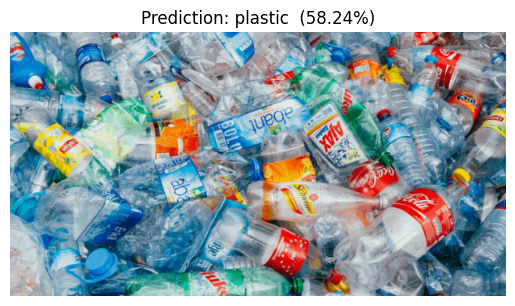

In [8]:
test_image_path = "./model/test_image.jpg"

if os.path.exists(test_image_path):
    predict_image(test_image_path)
else:
    print("Test image not found.")


**Conclusion**

The EcoSort AI model successfully classifies waste images using a CNN trained with Teachable Machine.  
This notebook demonstrates:

- Loading a trained Keras model  
- Preprocessing input images  
- Predicting waste categories  
- Visualizing predictions  

This completes the final project submission as a Jupyter Notebook.

---


  **Project Screenshot**

Below are the screenshots taken during the model testing and setup process.


 **1) VS Code Prediction Output**

This screenshot shows the model prediction running inside the VS Code terminal.

![VS Code Prediction](images/vscode_prediction.png)


 **2) Project Folder Structure**

This screenshot shows the folder structure of the EcoSort AI project.

![Folder Structure](images/folder_structure.png)


 **3) TensorFlow Version**

This screenshot verifies the TensorFlow version installed inside the virtual environment.

![TensorFlow Version](images/tf_version.png)


 **4) Model Loaded Successfully**

This screenshot shows the successful loading of the Keras model inside Jupyter Notebook.

![Model Loaded](images/model_loaded.png)


**5) Prediction Visualization Inside Notebook**

This is the output from the notebook showing the predicted waste class along with the confidence score and the input image.

![Notebook Prediction](images/notebook_prediction.png)
